# **Carga de Datos**

In [7]:
import pandas as pd
import joblib  # Librería estándar para cargar modelos

# --- CARGA DE ARTEFACTOS ---
print("Cargando inteligencia artificial y datos de prueba...")

# 1. CARGAR EL MODELO (El archivo .pkl o .joblib que guardaste al entrenar)

try:
    model_champion = joblib.load('modelo_final_xgboost.pkl')

    print("Modelo cargado exitosamente.")
except FileNotFoundError:
    print("ERROR: No encuentro el archivo del modelo. Verifica la ruta.")

# 2. CARGAR LOS DATOS DE PRUEBA (X_test e y_test)

try:

    X_test = pd.read_csv('X_test.csv', index_col=0)
    y_test = pd.read_csv('y_test.csv', index_col=0).squeeze() # .squeeze() lo convierte en Serie

    print(f"Datos cargados: {len(X_test)} clientes para simulación.")
except FileNotFoundError:
    print(" ERROR: No encuentro X_test.csv o y_test.csv.")

Cargando inteligencia artificial y datos de prueba...
Modelo cargado exitosamente.
Datos cargados: 18814 clientes para simulación.


Calculando Lift por Decil...
Tasa de Fuga Promedio Global: 20.0%


,Score_Min,Score_Max,Total_Clientes,Fugas_Reales,Tasa_Fuga,Lift,Cobertura_%
Decil,,,,,,,
1,69.2%,96.9%,1882,1234,65.6%,3.28x,32.8%
2,55.8%,69.2%,1881,834,44.3%,2.22x,55.0%
3,44.0%,55.8%,1881,651,34.6%,1.73x,72.4%
4,31.5%,44.0%,1881,453,24.1%,1.21x,84.4%
5,19.6%,31.5%,1882,300,15.9%,0.80x,92.4%
6,10.7%,19.6%,1881,143,7.6%,0.38x,96.2%
7,5.8%,10.7%,1880,73,3.9%,0.19x,98.1%
8,2.9%,5.8%,1883,43,2.3%,0.11x,99.3%
9,1.4%,2.9%,1881,17,0.9%,0.05x,99.7%


/tmp/ipython-input-1451839417.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=resumen.index, y=resumen['Lift'], palette="Blues_r")


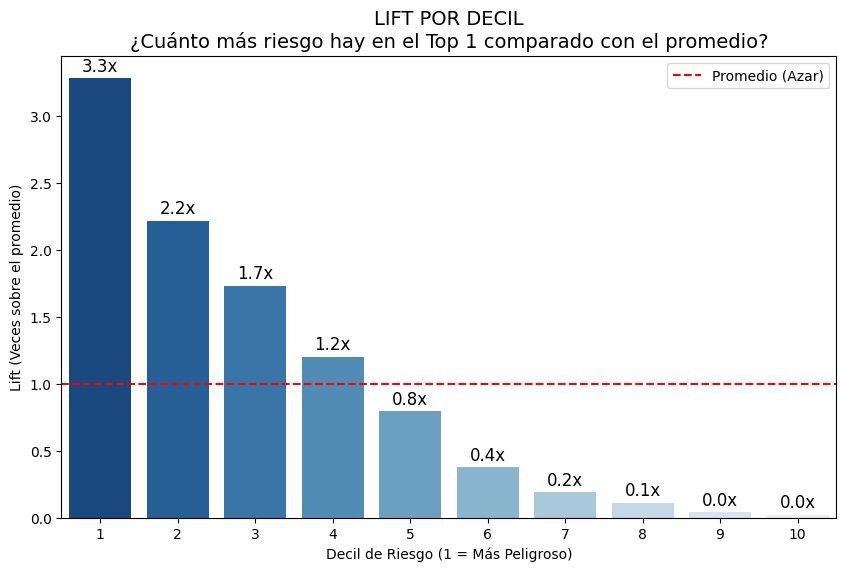

In [15]:
# ANÁLISIS DE CAPACIDAD PREDICTIVA (LIFT & DECILES)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Calculando Lift por Decil...")

# Prepara datos
df_lift = df_financiero.copy()

# 2. Crear Deciles (Dividir la base en 10 grupos iguales según probabilidad)
# Decil 1 = El 10% con mayor riesgo
# Decil 10 = El 10% con menor riesgo
try:
    df_lift['Decil'] = pd.qcut(df_lift['Probabilidad'], 10, labels=False, duplicates='drop')
    df_lift['Decil'] = 10 - df_lift['Decil'] # Invertimos para que 1 sea el más alto
except:
    # Fallback si hay muchos valores repetidos
    print("Nota: Usando ranking simple por duplicados en probabilidades.")
    df_lift['Rank'] = df_lift['Probabilidad'].rank(method='first')
    df_lift['Decil'] = pd.qcut(df_lift['Rank'], 10, labels=False)
    df_lift['Decil'] = 10 - df_lift['Decil']

# Calcula Métricas por Decil
resumen = df_lift.groupby('Decil').agg({
    'Probabilidad': ['min', 'max'],  # Rango de score
    'Es_Fuga_Real': ['count', 'sum', 'mean'] # Total clientes, Total Fugas, Tasa Fuga
})

# Limpia nombres de columnas
resumen.columns = ['Score_Min', 'Score_Max', 'Total_Clientes', 'Fugas_Reales', 'Tasa_Fuga']

# Calcula Métricas de Negocio (Lift y Cobertura)
tasa_promedio_global = df_lift['Es_Fuga_Real'].mean()

# Lift: ¿Cuántas veces mejor es este decil comparado con el promedio?
resumen['Lift'] = resumen['Tasa_Fuga'] / tasa_promedio_global

# Cobertura Acumulada: ¿Qué % del total de fugas tenemos atrapadas hasta aquí?
resumen['Fugas_Acumuladas'] = resumen['Fugas_Reales'].cumsum()
total_fugas = df_lift['Es_Fuga_Real'].sum()
resumen['Cobertura_%'] = (resumen['Fugas_Acumuladas'] / total_fugas) * 100

# Formato visual
print(f"Tasa de Fuga Promedio Global: {tasa_promedio_global:.1%}")
display(resumen[['Score_Min', 'Score_Max', 'Total_Clientes', 'Fugas_Reales', 'Tasa_Fuga', 'Lift', 'Cobertura_%']].style.format({
    'Score_Min': '{:.1%}', 'Score_Max': '{:.1%}',
    'Tasa_Fuga': '{:.1%}', 'Lift': '{:.2f}x', 'Cobertura_%': '{:.1f}%'
}).background_gradient(subset=['Lift'], cmap='RdYlGn'))

# GRÁFICO DE LIFT
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=resumen.index, y=resumen['Lift'], palette="Blues_r")

# Línea base (Lift = 1.0 es el azar)
plt.axhline(1.0, color='red', linestyle='--', label='Promedio (Azar)')
plt.title(f"LIFT POR DECIL\n¿Cuánto más riesgo hay en el Top 1 comparado con el promedio?", fontsize=14)
plt.xlabel("Decil de Riesgo (1 = Más Peligroso)")
plt.ylabel("Lift (Veces sobre el promedio)")
plt.legend()

# Etiquetas en las barras
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}x', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

# **Configuración de Parametros Financieros**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. PARAMETRIZACIÓN DETALLADA DEL NEGOCIO ---
print("--- DEFINIENDO ESTRUCTURA DE COSTOS ---")

# A. VALOR DEL CLIENTE
# Cuánto dinero nos deja el cliente en su vida útil promedio
LTV_CLIENTE = 7200000      # $7,200,000 COP

# B. COSTOS DE RETENCIÓN (DESAGREGADOS)
# 1. Costo Operativo: Lo que paga la empresa por el minuto, el agente, luz, sistemas.
COSTO_LLAMADA = 10000      # $10,000 COP (Costo Fijo por intento)

# 2. Costo Táctico: El dinero que dejamos de recibir por dar el descuento o regalo.
COSTO_INCENTIVO = 180000   # $180,000 COP (Costo Variable promedio)

# Costo Total Unitario (Para cálculos simples)
COSTO_TOTAL = COSTO_LLAMADA + COSTO_INCENTIVO # $190,000 COP

# C. EFICIENCIA OPERATIVA
TASA_EXITO = 0.30          # 30% (De cada 10 fugas reales, salvamos 3)
PRESUPUESTO_N = 10000      # Capacidad del Call Center (10k llamadas)

# Validación Visual
print(f"LTV por Cliente:     ${LTV_CLIENTE:,.0f}")
print(f"Costo Operativo:     ${COSTO_LLAMADA:,.0f} (Gestión)")
print(f"Costo Incentivo:     ${COSTO_INCENTIVO:,.0f} (Descuento)")
print(f"---------------------------------------")
print(f"COSTO TOTAL GESTIÓN: ${COSTO_TOTAL:,.0f}")

--- DEFINIENDO ESTRUCTURA DE COSTOS ---
LTV por Cliente:     $7,200,000
Costo Operativo:     $10,000 (Gestión)
Costo Incentivo:     $180,000 (Descuento)
---------------------------------------
COSTO TOTAL GESTIÓN: $190,000


# **Construcción de la Base Financiera -Backtesting**

Cruzamos la predicción del modelo con la realidad para poder hacer cálculos honestos (Backtesting).

In [9]:
# --- 2. CONSTRUCCIÓN DE LA BASE FINANCIERA ---

print("Generando predicciones para simulación...")

# DataFrame maestro para cálculos
df_financiero = pd.DataFrame({
    # 1. LA PREDICCIÓN: La probabilidad de fuga que calcula el modelo
    'Probabilidad': model_champion.predict_proba(X_test)[:, 1],

    # 2. LA REALIDAD: ¿Ese cliente realmente se fue? (Vital para saber si ganamos dinero)
    'Es_Fuga_Real': y_test
}, index=X_test.index)

print(f"Base financiera generada exitosamente.")
print(f"   - Total Clientes en prueba: {len(df_financiero):,.0f}")
print(f"   - Fugas Reales ocultas:     {df_financiero['Es_Fuga_Real'].sum():,.0f}")

Generando predicciones para simulación...
Base financiera generada exitosamente.
   - Total Clientes en prueba: 18,814
   - Fugas Reales ocultas:     3,758


# **El Motor de Cálculo (Función ROI)**
Esta es la función que calcula el dinero. Recibe la base y los supuestos, y devuelve la Ganancia Neta.

In [10]:
# --- 3. DEFINICIÓN DEL MOTOR DE ROI ---

def calcular_roi(df, ltv, costo, tasa_exito, umbral=None, top_n=None):
    """
    Calcula el P&L (Ganancias y Pérdidas) de la campaña.
    """
    df_calc = df.copy()

    # A. DEFINIR A QUIÉN LLAMAMOS (TARGETING)
    if top_n:
        # Estrategia Presupuesto: Ordenamos por riesgo y tomamos los Top N
        df_calc = df_calc.sort_values('Probabilidad', ascending=False)
        df_calc['Gestionar'] = False
        limit = min(top_n, len(df_calc))
        df_calc.iloc[:limit, df_calc.columns.get_loc('Gestionar')] = True
    elif umbral:
        # Estrategia Rentabilidad: Cortamos por probabilidad fija
        df_calc['Gestionar'] = df_calc['Probabilidad'] >= umbral
    else:
        return None

    # B. COSTOS
    n_gestionados = df_calc['Gestionar'].sum()
    costo_total = n_gestionados * costo

    # C. INGRESOS (SOLO SI ES FUGA REAL + AGENTE ÉXITOSO)
    fugas_reales_tocadas = df_calc[df_calc['Gestionar']]['Es_Fuga_Real'].sum()
    clientes_salvados = int(fugas_reales_tocadas * tasa_exito)

    # D. RESULTADO
    ingreso_bruto = clientes_salvados * ltv
    profit = ingreso_bruto - costo_total
    roi = (profit / costo_total) * 100 if costo_total > 0 else 0

    return {
        'Clientes_Gestionados': n_gestionados,
        'Fugas_Reales_Detectadas': fugas_reales_tocadas,
        'Clientes_Salvados': clientes_salvados,
        'Inversión': costo_total,
        'Retorno_Bruto': ingreso_bruto,
        'Ganancia_Neta': profit,
        'ROI_Porcentaje': roi
    }

print("Motor financiero activado.")

Motor financiero activado.


# **Simulación A - Optimización (Curva)**
Busca el umbral matemático donde la empresa gana más dinero.

`*`*Esta gráfica nos dirá si deberíamos llamar a más o menos gente de la que pensábamos.*`*`

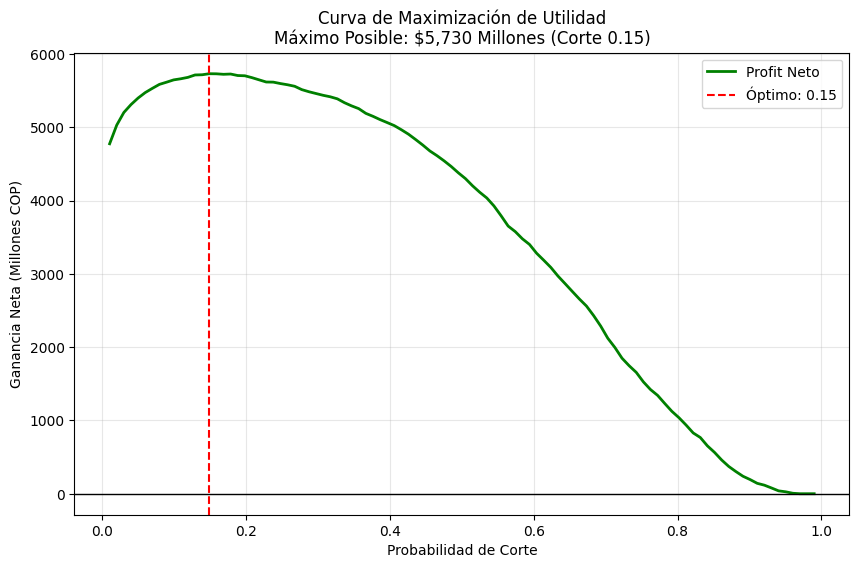

CONCLUSIÓN: El umbral que maximiza el dinero es 0.15


In [11]:
# SIMULACIÓN: CURVA DE OPTIMIZACIÓN FINANCIERA

umb_lista = np.linspace(0.01, 0.99, 100)
ganancias = []

# Iteramos sobre cada umbral posible
for u in umb_lista:
    res = calcular_roi(df_financiero, LTV_CLIENTE, COSTO_TOTAL, TASA_EXITO, umbral=u)
    ganancias.append(res['Ganancia_Neta'])

# Encontrar el pico máximo
idx_max = np.argmax(ganancias)
max_ganancia = ganancias[idx_max]
mejor_umbral = umb_lista[idx_max]

# Graficar
plt.figure(figsize=(10, 6))
plt.plot(umb_lista, [g/1e6 for g in ganancias], color='green', linewidth=2, label='Profit Neto')
plt.axvline(mejor_umbral, color='red', linestyle='--', label=f'Óptimo: {mejor_umbral:.2f}')
plt.axhline(0, color='black', linewidth=1)

plt.title(f"Curva de Maximización de Utilidad\nMáximo Posible: ${max_ganancia/1e6:,.0f} Millones (Corte {mejor_umbral:.2f})")
plt.xlabel("Probabilidad de Corte")
plt.ylabel("Ganancia Neta (Millones COP)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"CONCLUSIÓN: El umbral que maximiza el dinero es {mejor_umbral:.2f}")

# **Simulación B - Escenario Realista (Top N)**

Simula el resultado operativo de gestionar tu base actual (los 9.404 clientes o tu presupuesto de 10k).

`*`*Tengo plata para 10,000 llamadas. ¿Cuánto gano?*`*`

In [12]:
#  REPORTE EJECUTIVO: ESCENARIO PRESUPUESTO FIJO

# Calculamos ROI para tu capacidad de 10,000 (o el total de la base)

META_GESTION = 10000
res_topn = calcular_roi(df_financiero, LTV_CLIENTE, COSTO_TOTAL, TASA_EXITO, top_n=META_GESTION)

print(f"--- RESULTADOS PROYECTADOS (TOP {META_GESTION} GESTIONES) ---")
print(f"1. Inversión Requerida:  ${res_topn['Inversión']/1e6:,.1f} M")
print(f"2. Fugas Reales Atacadas:{res_topn['Fugas_Reales_Detectadas']} clientes")
print(f"3. Clientes Salvados:    {res_topn['Clientes_Salvados']} (al {TASA_EXITO:.0%} de éxito)")
print(f"--------------------------------------------------")
print(f"GANANCIA NETA:           ${res_topn['Ganancia_Neta']/1e6:,.1f} MILLONES")
print(f"ROI DE LA INVERSIÓN:     {res_topn['ROI_Porcentaje']:.0f}%")

--- RESULTADOS PROYECTADOS (TOP 10000 GESTIONES) ---
1. Inversión Requerida:  $1,900.0 M
2. Fugas Reales Atacadas:3534 clientes
3. Clientes Salvados:    1060 (al 30% de éxito)
--------------------------------------------------
GANANCIA NETA:           $5,732.0 MILLONES
ROI DE LA INVERSIÓN:     302%


# **Simulación C - Sensibilidad (Incentivos/ What-If)**
Esta es la gráfica "Estratégica". Muestra qué pasa si subimos o bajamos el incentivo.

Simulando escenarios de incentivos...


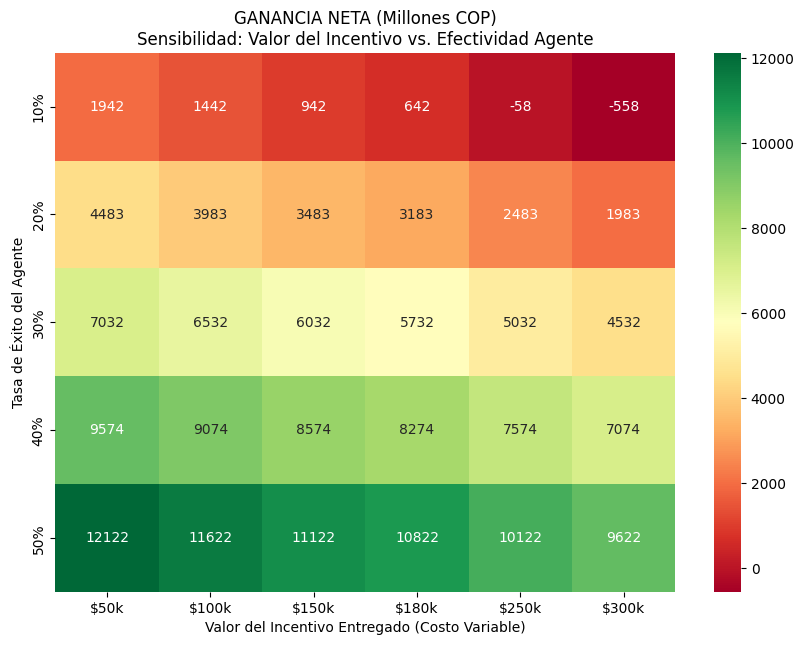

In [13]:
# ANÁLISIS DE SENSIBILIDAD: TAMAÑO DEL INCENTIVO VS ÉXITO

# Rango de Incentivos: Desde $50k hasta $300k y Éxito (10% a 50%)
lista_incentivos = [50000, 100000, 150000, 180000, 250000, 300000]
lista_exito = [0.10, 0.20, 0.30, 0.40, 0.50]

matriz = np.zeros((len(lista_exito), len(lista_incentivos)))

print("Simulando escenarios de incentivos...")

for i, exito in enumerate(lista_exito):
    for j, incentivo in enumerate(lista_incentivos):

        # CÁLCULO DINÁMICO: Costo Fijo ($10k) + Incentivo Variable
        costo_escenario = COSTO_LLAMADA + incentivo

        # Corremos el motor
        res = calcular_roi(df_financiero, LTV_CLIENTE, costo_escenario, exito, top_n=META_GESTION)

        # Guardamos Ganancia en Millones
        matriz[i, j] = res['Ganancia_Neta'] / 1e6

# Heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(matriz, annot=True, fmt=".0f", cmap="RdYlGn",
            xticklabels=[f"${inc/1000:.0f}k" for inc in lista_incentivos],
            yticklabels=[f"{e:.0%}" for e in lista_exito])

plt.title(f"GANANCIA NETA (Millones COP)\nSensibilidad: Valor del Incentivo vs. Efectividad Agente")
plt.xlabel("Valor del Incentivo Entregado (Costo Variable)")
plt.ylabel("Tasa de Éxito del Agente")
plt.show()

# **Listas con A/B Testing (80/20)**
Genera los archivos científicos para la propuesta de implementación.

In [14]:
# EXPORTACIÓN CON A/B TESTING (80/20)

# 1. Selecciona los Top 10,000 candidatos (La capacidad operativa)
df_final = df_financiero.sort_values('Probabilidad', ascending=False).head(META_GESTION).copy()

# 2. Divide aleatoriamente: 80% Gestionar, 20% Control
np.random.seed(42)
df_final['Grupo'] = np.random.choice(
    ['TRATAMIENTO (Llamar)', 'CONTROL (No Llamar)'],
    size=len(df_final),
    p=[0.80, 0.20]
)

# 3. Guarda los archivos
gestion = df_final[df_final['Grupo'] == 'TRATAMIENTO (Llamar)']
control = df_final[df_final['Grupo'] == 'CONTROL (No Llamar)']

gestion.to_csv("LISTA_GESTION_OPERATIVA.csv")
control.to_csv("LISTA_CONTROL_AUDITORIA.csv")

print(f"--- LISTAS GENERADAS PARA IMPLEMENTACIÓN ---")
print(f"Total Clientes Seleccionados: {len(df_final)}")
print(f"1. A GESTIONAR (Call Center): {len(gestion)} clientes (80%)")
print(f"2. GRUPO CONTROL (Auditoría): {len(control)} clientes (20%)")

--- LISTAS GENERADAS PARA IMPLEMENTACIÓN ---
Total Clientes Seleccionados: 10000
1. A GESTIONAR (Call Center): 8038 clientes (80%)
2. GRUPO CONTROL (Auditoría): 1962 clientes (20%)
